# Vietnamese Product Reviews — Sentiment Analysis with SVM and Naive Bayes

**Yêu cầu:** *Perform sentiment analysis using SVM and Naive Bayes and compare the results.*



## 1. Load Dataset

Gắn [Vietnamese Text Classification Dataset](https://www.kaggle.com/datasets/tuannguyenvananh/vietnamese-text-classification-dataset) qua **Add Input**. Đọc toàn bộ **3,040 mẫu** từ `train.csv`, dùng `header=None` vì cột đầu là nhãn, cột sau là văn bản và file không có dòng tiêu đề.

Data Card chưa công bố định nghĩa nhãn nên báo cáo giữ nguyên tên lớp **0, 1, 2**. Chạy bằng **CPU**, bật Internet để cài `underthesea`.


In [1]:
%pip install -q "underthesea==8.3.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.4/978.4 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
import re
import unicodedata
from pathlib import Path
from time import perf_counter

import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import Markdown, display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from underthesea import word_tokenize

SEED = 42
LABELS = [0, 1, 2]
print('scikit-learn:', sklearn.__version__)

scikit-learn: 1.6.1


In [3]:
files = sorted(p for p in Path('/kaggle/input').rglob('train.csv')
               if 'vietnamese-text-classification-dataset' in p.parts)
if len(files) != 1:
    raise ValueError(f'Cần gắn đúng dataset Kaggle được giao. Các file tìm thấy: {files}')
DATA_PATH = files[0]
CLASS_NAMES = ['0', '1', '2']
OUTPUT_NAME = 'kaggle_reviews_results.csv'
raw_df = pd.read_csv(DATA_PATH, header=None, encoding='utf-8-sig')
if raw_df.shape[1] != 2:
    raise ValueError('train.csv phải có đúng 2 cột: nhãn, văn bản.')
raw_df.columns = ['label', 'text']
raw_df['label'] = pd.to_numeric(raw_df['label'], errors='raise')
if not raw_df['label'].dropna().isin(LABELS).all():
    raise ValueError('Nhãn phải thuộc 0, 1, 2.')
print('File:', DATA_PATH, '| Số mẫu ban đầu:', len(raw_df))
display(raw_df.head())

File: /kaggle/input/datasets/tuannguyenvananh/vietnamese-text-classification-dataset/train.csv | Số mẫu ban đầu: 3040


,label,text
0,0,máy dùng hay bị đơ máy
1,0,chỉ có dây cáp nguồn không có adapter sao sử d...
2,0,Chất lượng quá kém Mới dùng được 2 ngày loa ba...
3,0,Usb tôi vừa mới nhận usb này Rất bực bội vì cá...
4,2,Tuyệt vời. Hàng FPT cửa hàng


## 2. Prepare Text

Chuẩn hóa Unicode NFC, lowercase, xóa HTML/URL/dấu câu, chuẩn hóa khoảng trắng và tách từ tiếng Việt bằng `underthesea`. Giữ dấu tiếng Việt và stopword, đặc biệt các từ phủ định như **không, chưa, chẳng**.


In [4]:
def preprocess(text):
    text = unicodedata.normalize('NFC', text).lower()
    text = re.sub(r'https?://\S+|www\.\S+|<[^>]+>', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return word_tokenize(text, format='text') if text else ''


def prepare_text(frame):
    frame = frame.dropna(subset=['text', 'label']).copy()
    frame['processed_text'] = frame['text'].map(preprocess)
    return frame.loc[frame['processed_text'].str.strip().ne('')].copy()


def deduplicate(frame):
    # Loại toàn bộ nhóm có cùng văn bản nhưng khác nhãn; giữ một mẫu nếu cùng nhãn.
    conflicts = frame.groupby('processed_text')['label'].transform('nunique').gt(1)
    return frame.loc[~conflicts].drop_duplicates('processed_text').reset_index(drop=True)

## 3. Train-Test Split

Loại văn bản rỗng, mẫu trùng và nhóm có cùng văn bản nhưng khác nhãn trước khi chia: từ **3,040** còn **2,991 mẫu**, loại **49 mẫu**.

Chia **80% train / 20% test** với `stratify` theo nhãn và `random_state=42`: **2,392 mẫu train**, **599 mẫu test**. Không lấy mẫu giới hạn dữ liệu.


In [5]:
df = deduplicate(prepare_text(raw_df))
df['label'] = df['label'].astype(int)
print('Số mẫu hợp lệ:', len(df), '| Đã loại:', len(raw_df) - len(df))
train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df['label'], random_state=SEED,
)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

assert set(y for y in train_df['label']) == set(LABELS)
assert set(y for y in test_df['label']) == set(LABELS)
assert set(train_df['processed_text']).isdisjoint(test_df['processed_text'])
distribution = pd.DataFrame({
    'Train': train_df['label'].value_counts(),
    'Test': test_df['label'].value_counts(),
}).reindex(LABELS).fillna(0).astype(int)
distribution.index = CLASS_NAMES
display(distribution)
display(train_df[['text', 'processed_text', 'label']].head(3))

Số mẫu hợp lệ: 2991 | Đã loại: 49


,Train,Test
0,870,218
1,691,173
2,831,208


,text,processed_text,label
0,"gói hàng cẩn thận,giao nhanh,chị giao hàng nhi...",gói hàng cẩn_thận giao nhanh chị giao hàng nhi...,2
1,bình thường bị khui trước rồi không biết có bị...,bình_thường bị khui trước rồi không biết có bị...,1
2,chào... sao không thấy chân máy giặt.. và qua ...,chào_sao không thấy chân máy_giặt và qua tặng ...,0


## 4. TF-IDF Features

Dùng chung **TF-IDF unigram + bigram**, tối đa **20,000 đặc trưng**, cho cả hai mô hình.
Chỉ học vocabulary và IDF trên train; test chỉ được `transform` để tránh rò rỉ dữ liệu.

TF-IDF có giá trị không âm, phù hợp với Multinomial Naive Bayes. 

In [6]:
vectorizer = TfidfVectorizer(
    tokenizer=str.split, token_pattern=None, lowercase=False,
    ngram_range=(1, 2), min_df=2, max_features=20000, sublinear_tf=True,
)
X_train = vectorizer.fit_transform(train_df['processed_text'])
X_test = vectorizer.transform(test_df['processed_text'])
y_train = train_df['label']
y_test = test_df['label']
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (2392, 8882) | Test: (599, 8882)


## 5. Train and Compare Models

- **SVM (`LinearSVC`)** học ranh giới tuyến tính với biên phân cách lớn, cân bằng với lỗi huấn luyện qua `C`. Dùng `C=1.0`; phân loại nhiều lớp theo one-vs-rest.
- **Naive Bayes (`MultinomialNB`)** áp dụng định lý Bayes với giả định các đặc trưng độc lập có điều kiện theo lớp. Dùng `alpha=1.0` (Laplace smoothing) để tránh xác suất bằng 0 cho đặc trưng chưa xuất hiện trong lớp.

Hai mô hình dùng cùng dữ liệu và ma trận TF-IDF, giữ cố định tham số. So sánh chính bằng **Macro-F1** (trung bình F1 với trọng số bằng nhau cho các lớp), kèm Accuracy, Precision và Recall. Thời gian trong bảng chỉ tính `fit`/`predict` của bộ phân loại, không gồm tiền xử lý và TF-IDF.


In [7]:
models = {
    'SVM': LinearSVC(C=1.0, dual=True, max_iter=10000, random_state=SEED),
    'Naive Bayes': MultinomialNB(alpha=1.0),
}
rows, predictions, reports = [], {}, {}
for name, model in models.items():
    start = perf_counter()
    model.fit(X_train, y_train)
    train_seconds = perf_counter() - start
    start = perf_counter()
    pred = model.predict(X_test)
    predict_seconds = perf_counter() - start
    predictions[name] = pred
    report = classification_report(
        y_test, pred, labels=LABELS, target_names=CLASS_NAMES,
        output_dict=True, zero_division=0,
    )
    reports[name] = pd.DataFrame(report).T
    rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision (macro)': report['macro avg']['precision'],
        'Recall (macro)': report['macro avg']['recall'],
        'F1 (macro)': report['macro avg']['f1-score'],
        'Train (s)': train_seconds,
        'Predict (s)': predict_seconds,
    })

results = pd.DataFrame(rows).set_index('Model')
display(results.round(4))

,Accuracy,Precision (macro),Recall (macro),F1 (macro),Train (s),Predict (s)
Model,,,,,,
SVM,0.8097,0.802,0.7986,0.7987,0.0393,0.0006
Naive Bayes,0.7579,0.760,0.7343,0.7214,0.0054,0.0005


## 6. Per-Class Evaluation

Báo cáo Precision, Recall, F1 và số mẫu (`support`) của từng lớp. Confusion matrix có hàng là nhãn thật, cột là nhãn dự đoán; các ô ngoài đường chéo thể hiện lỗi phân loại.


### SVM

,precision,recall,f1-score,support
0,0.8091,0.8945,0.8497,218.0
1,0.7190,0.6358,0.6748,173.0
2,0.8780,0.8654,0.8717,208.0


### Naive Bayes

,precision,recall,f1-score,support
0,0.7246,0.9174,0.8097,218.0
1,0.7586,0.3815,0.5077,173.0
2,0.7966,0.9038,0.8468,208.0


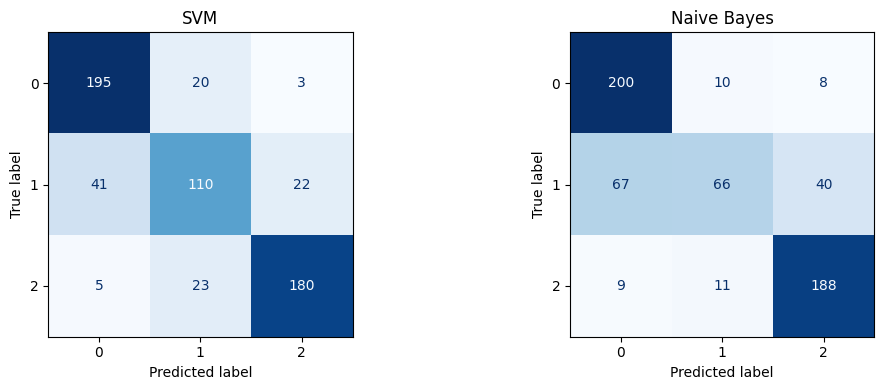

In [8]:
for name, report in reports.items():
    display(Markdown(f'### {name}'))
    display(report.loc[CLASS_NAMES, ['precision', 'recall', 'f1-score', 'support']].round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, pred) in zip(axes, predictions.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred, labels=LABELS, display_labels=CLASS_NAMES,
        cmap='Blues', colorbar=False, ax=ax,
    )
    ax.set_title(name)
plt.tight_layout()
plt.show()

## 7. Results and Conclusion

SVM đạt F1 cao hơn Naive Bayes ở cả ba lớp. Lớp **1** khó phân loại nhất: SVM nhận đúng **110/173** mẫu, Naive Bayes nhận đúng **66/173** mẫu; tương ứng F1 là **0.6748** và **0.5077**. Với cấu hình này, SVM cho chất lượng phân loại tốt hơn, còn Naive Bayes huấn luyện nhanh hơn.

Kết luận chỉ áp dụng cho lần chia test hiện tại. Thời gian toàn notebook theo log Kaggle là **77.3 giây**. Cell dưới báo cáo số liệu và xuất bảng CSV.


In [9]:
delta = results.loc['SVM', 'F1 (macro)'] - results.loc['Naive Bayes', 'F1 (macro)']
if abs(delta) < 1e-12:
    comparison = 'Hai mô hình có Macro-F1 bằng nhau trên tập test này.'
else:
    better = 'SVM' if delta > 0 else 'Naive Bayes'
    comparison = f'{better} có Macro-F1 cao hơn {abs(delta) * 100:.2f} điểm phần trăm trên tập test này.'
notes = [comparison]
for name in models:
    row = results.loc[name]
    weakest = reports[name].loc[CLASS_NAMES, 'f1-score'].idxmin()
    notes.append(
        f"**{name}**: Accuracy = {row['Accuracy']:.4f}, Macro-F1 = {row['F1 (macro)']:.4f}; "
        f"lớp có F1 thấp nhất là **{weakest}** ({reports[name].loc[weakest, 'f1-score']:.4f})."
    )
faster = results['Train (s)'].idxmin()
notes.append(f'{faster} có thời gian huấn luyện ngắn hơn trong lần chạy này; thời gian phụ thuộc môi trường CPU.')
display(Markdown('\n\n'.join(notes)))

output_dir = Path('/kaggle/working')
output_dir.mkdir(parents=True, exist_ok=True)
results.to_csv(output_dir / OUTPUT_NAME, encoding='utf-8-sig')

SVM có Macro-F1 cao hơn 7.73 điểm phần trăm trên tập test này.

**SVM**: Accuracy = 0.8097, Macro-F1 = 0.7987; lớp có F1 thấp nhất là **1** (0.6748).

**Naive Bayes**: Accuracy = 0.7579, Macro-F1 = 0.7214; lớp có F1 thấp nhất là **1** (0.5077).

Naive Bayes có thời gian huấn luyện ngắn hơn trong lần chạy này; thời gian phụ thuộc môi trường CPU.